# J-Lens Bias — Week 1: End-to-End Jacobian Lens Readout Pipeline

**Goal.** Reproduce Anthropic's Jacobian Lens workflow end-to-end, generate an interactive slice-vis grid, extract the same readout programmatically with `lens.apply()`, run the extraction over prompts from `data/experiments/`, and produce a per-layer summary aggregated over all prompts and positions.

This notebook deliberately **does not run bias experiments**. Week 1 is about making the measurement pipeline correct, reproducible, and easy to inspect.

## What this notebook produces

1. A working Qwen model + pre-fitted Jacobian Lens.
2. A full **position × layer** slice-vis page.
3. A programmatic table with one row for every:

   \[
   \text{prompt} \times \text{layer} \times \text{position}
   \]

4. For each cell:
   - source token / source position,
   - the **displayed top-1 word-like J-Lens token**,
   - that token's **true rank in the full model vocabulary**,
   - reciprocal rank,
   - whether it is rank ≤ 1, 5, 10, 100.
5. A **per-layer summary table** in the spirit of Anthropic's layer-wise analysis.
6. Layer-wise plots and a slice-style heatmap.
7. A direct validation that our `lens.apply()` extraction agrees with Anthropic's `compute_slice(..., mask_display=True)`.

> **Important rank convention:** Anthropic's slice-vis can hide punctuation/special/non-word tokens while keeping ranks measured against the **full vocabulary**. Therefore the displayed "top-1" word-like token can have a full-vocabulary rank greater than 1. In this notebook, ranks are reported **1-based** for readability: rank 1 = best token in the full vocabulary.

## 0. Reproducibility notes

The assignment asks for **Qwen3.6-27B** with a pre-fitted lens, but that model needs roughly 55+ GB just for BF16 weights and is usually impractical on standard Colab storage/GPU. This notebook therefore defaults to the explicitly permitted **Qwen3.5-4B** fallback with its matching 1000-prompt lens.

The notebook is written for Colab but also auto-detects a local `jacobian-lens` checkout. It does **not** change the working directory, so paths remain stable across reruns.

For exact slice-vis parity, the extraction uses the same `_meaningful_token_mask`, `_ranks_of`, and `topk(K)` behavior as the repository's current `compute_slice(..., mask_display=True)` implementation.

Keep the final executed notebook outputs when submitting.


In [5]:
import os
from pathlib import Path

REPO_DIR = Path("/content/jacobian-lens")

# Clone only if it isn't already present
if not REPO_DIR.exists():
    !git clone https://github.com/anthropics/jacobian-lens.git /content/jacobian-lens

# Install into THIS notebook's Python environment
%pip install -e /content/jacobian-lens# Run once in a fresh Colab/runtime. This cell is idempotent: it will not
# clone the repository again if /content/jacobian-lens already exists.
from pathlib import Path
import subprocess
import sys

COLAB_REPO = Path("/content/jacobian-lens")

if not COLAB_REPO.exists():
    subprocess.run(
…subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "matplotlib", "tqdm", "huggingface_hub", "accelerate"],
    check=True,
)

print("Installation complete.")


Obtaining file:///content/jacobian-lens
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jlens (pyproject.toml) ... done
  Created wheel for jlens: filename=jlens-0.1.0-0.editable-py3-none-any.whl size=8901 sha256=b5be962f378ed94bc77eab5283a2474482ed06b08af74701e72b2c41ec73db01
  Stored in directory: /tmp/pip-ephem-wheel-cache-8dzbeu2_/wheels/9b/16/f6/ff5117e12d375117559a1ded186e4d458b172d145efd7f032b
Successfully built jlens
  Attempting uninstall: jlens
    Found existing installation: jlens 0.1.0
    Uninstalling jlens-0.1.0:
      Successfully uninstalled jlens-0.1.0


In [8]:
import sys
from pathlib import Path

REPO_DIR = Path("/content/jacobian-lens")
sys.path.insert(0, str(REPO_DIR))

# Verify the editable install without cloning/changing directory a second time.
import jlens

print("jlens imported successfully")
print("jlens module:", jlens.__file__)
print("Anthropic checkout exists:", Path("/content/jacobian-lens").exists())


jlens imported successfully
jlens module: /content/jacobian-lens/jlens/__init__.py
Anthropic checkout exists: True


In [9]:
# If this import succeeds, continue to the main imports/configuration below.
import jlens
print("jlens version check passed:", jlens.__file__)


jlens version check passed: /content/jacobian-lens/jlens/__init__.py


## 1. Imports and configuration

Change only the configuration block first. The rest of the notebook is written so that the same analysis code works for the large model and the smaller fallback.

In [24]:
from __future__ import annotations

import gc
import json
import platform
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import transformers
import jlens
from jlens.vis import (
    compute_slice,
    build_page,
    notebook_iframe,
    _meaningful_token_mask,
    _ranks_of,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("jlens:", jlens.__file__)
print("Platform:", platform.platform())
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
jlens: /content/jacobian-lens/jlens/__init__.py
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CUDA available: True
GPU: Tesla T4
CUDA capability: (7, 5)


In [25]:
# Optional storage diagnostic (useful on Colab before loading a model).
import shutil
from pathlib import Path

usage = shutil.disk_usage("/")
print(f"Disk total: {usage.total / 2**30:.1f} GiB")
print(f"Disk used:  {usage.used / 2**30:.1f} GiB")
print(f"Disk free:  {usage.free / 2**30:.1f} GiB")

hf_cache = Path.home() / ".cache" / "huggingface"
print("Hugging Face cache:", hf_cache)


Disk total: 112.6 GiB
Disk used:  56.4 GiB
Disk free:  56.2 GiB
Hugging Face cache: /root/.cache/huggingface


In [26]:
# =========================
# MODEL / LENS CONFIGURATION
# =========================

# Standard Colab cannot comfortably host the 27B BF16 model, so default to
# the assignment-permitted smaller model. Set False only on suitable hardware.
USE_SMALLER_MODEL = True

if not USE_SMALLER_MODEL:
    MODEL_ID = "Qwen/Qwen3.6-27B"
    LENS_REPO = "neuronpedia/jacobian-lens"
    LENS_FILENAME = (
        "qwen3.6-27b/jlens/Salesforce-wikitext/"
        "Qwen3.6-27B_jacobian_lens_n1000.pt"
    )
else:
    MODEL_ID = "Qwen/Qwen3.5-4B"
    LENS_REPO = "neuronpedia/jacobian-lens"
    LENS_FILENAME = (
        "qwen3.5-4b/jlens/Salesforce-wikitext/"
        "Qwen3.5-4B_jacobian_lens_n1000.pt"
    )

MAX_SEQ_LEN = 256
MAX_EXPERIMENT_PROMPTS = 20
SLICE_TOP_N = 10  # must match extraction helper for exact slice-vis validation

# Auto-detect the Anthropic checkout rather than assuming Path('.').
repo_candidates = [
    Path("/content/jacobian-lens"),
    Path.cwd(),
    Path.cwd() / "jacobian-lens",
]
ANTHROPIC_REPO = next(
    (
        p.resolve()
        for p in repo_candidates
        if (p / "jlens").exists() and (p / "data" / "experiments").exists()
    ),
    None,
)
if ANTHROPIC_REPO is None:
    raise FileNotFoundError(
        "Could not locate the anthropics/jacobian-lens checkout. "
        "Run the installation cell first or set ANTHROPIC_REPO manually."
    )

EXPERIMENT_DIR = ANTHROPIC_REPO / "data" / "experiments"
OUTPUT_DIR = Path.cwd() / "week1_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_ID:", MODEL_ID)
print("LENS_FILENAME:", LENS_FILENAME)
print("ANTHROPIC_REPO:", ANTHROPIC_REPO)
print("EXPERIMENT_DIR:", EXPERIMENT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


MODEL_ID: Qwen/Qwen3.5-4B
LENS_FILENAME: qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt
ANTHROPIC_REPO: /content/jacobian-lens
EXPERIMENT_DIR: /content/jacobian-lens/data/experiments
OUTPUT_DIR: /content/week1_outputs


## 2. Load the Qwen model and wrap it for `jlens`

`jlens.from_hf(...)` adapts a Hugging Face decoder model to the interface expected by the Jacobian Lens.

The model is loaded in `bfloat16` on CUDA when available. Qwen3.6-27B normally requires substantial GPU memory; use an environment appropriate for the model or switch to the fallback above.

In [27]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is strongly recommended for this notebook. "
        "For a CPU-only smoke test, switch to a much smaller supported model."
    )

dtype = torch.bfloat16

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = transformers.AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)

hf_model.eval()

# Make repeated validation passes as deterministic as the backend allows.
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

model = jlens.from_hf(hf_model, tokenizer)

print("HF model training mode:", hf_model.training)
print(model)
print("n_layers:", model.n_layers)
print("d_model:", model.d_model)
print("vocab size:", len(tokenizer))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

HF model training mode: False
HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)
n_layers: 32
d_model: 2560
vocab size: 248077


## 3. Load the pre-fitted Jacobian Lens

A fitted Jacobian Lens stores one average Jacobian transport matrix \(J_\ell\) for each fitted source layer. We are **loading**, not fitting, the lens.

In [28]:
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO,
    filename=LENS_FILENAME,
)

print(lens)
print("Number of fitted source layers:", len(lens.source_layers))
print("First fitted layer:", lens.source_layers[0])
print("Last fitted layer:", lens.source_layers[-1])
print("Lens d_model:", lens.d_model)
print("Model d_model:", model.d_model)

assert lens.d_model == model.d_model, (
    f"Lens/model mismatch: lens d_model={lens.d_model}, "
    f"model d_model={model.d_model}"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))
Number of fitted source layers: 31
First fitted layer: 0
Last fitted layer: 30
Lens d_model: 2560
Model d_model: 2560


## 4. First `lens.apply()` smoke test

The official interface returns:

```python
lens_logits, model_logits, input_ids = lens.apply(...)
```

where `lens_logits[layer]` has shape `[n_positions, vocab_size]`, `model_logits` contains the actual final-layer readout at those same positions, and `input_ids` contains the tokenized prompt.

First we inspect only the final prompt position and a handful of layers.

In [29]:
SMOKE_PROMPT = "Fact: The currency used in the country shaped like a boot is"

sample_layers = lens.source_layers[::max(1, len(lens.source_layers)//6)]
sample_layers = sorted(set(sample_layers + [lens.source_layers[-1]]))

lens_logits, model_logits, input_ids = lens.apply(
    model,
    SMOKE_PROMPT,
    layers=sample_layers,
    positions=[-1],
    max_seq_len=MAX_SEQ_LEN,
)

print("Prompt:", SMOKE_PROMPT)
print("Token count:", input_ids.shape[1])
print("Sample layers:", sample_layers)
print()

for layer in sample_layers:
    top = lens_logits[layer][0].topk(5)
    words = [
        tokenizer.decode([int(t)], clean_up_tokenization_spaces=False)
        for t in top.indices
    ]
    print(f"L{layer:02d}:", list(zip(words, top.values.tolist())))

Prompt: Fact: The currency used in the country shaped like a boot is
Token count: 13
Sample layers: [0, 5, 10, 15, 20, 25, 30]

L00: [(" '", 11.125), (' ...', 10.875), (' --', 10.5625), (' however', 10.0625), (' -', 10.0625)]
L05: [('...', 22.0), ('.', 20.0), (' ...', 19.875), (' [...]', 16.125), ('.\\', 16.0)]
L10: [(' ...', 19.75), ('...', 18.75), (' [...]', 18.0), (' ...\\', 16.375), ('____', 15.875)]
L15: [('____', 22.625), ('?\\', 20.375), ('\\n', 20.0), ('________', 19.875), ('\\"', 19.75)]
L20: [('.\\', 15.5625), ('\\"', 14.75), ('.\\"', 14.625), (' currency', 14.5), ('____', 14.375)]
L25: [(' euros', 23.5), (' euro', 23.5), (' Euro', 22.5), ('欧元', 21.5), (' Euros', 21.375)]
L30: [(' Euro', 17.75), (' the', 17.0), (' Euros', 16.875), (' euros', 16.25), (' euro', 15.625)]


## 5. Generate a full Anthropic slice-vis page

`compute_slice` creates the layer × position data used by Anthropic's interactive visualization.

We use `layer_stride=1` for every fitted layer, `last_n_tokens=None` for every prompt position, and `mask_display=True` so the cell displays the highest-ranked **word-like** token while preserving its rank against the **full vocabulary**.

The final model layer is also included by the visualization as the actual model-output row.

In [30]:
slice_data = compute_slice(
    model,
    lens,
    SMOKE_PROMPT,
    top_n=SLICE_TOP_N,
    layer_stride=1,
    last_n_tokens=None,
    max_seq_len=MAX_SEQ_LEN,
    mask_display=True,
)

slice_html, raw_bytes, payload_bytes = build_page(
    slice_data,
    SMOKE_PROMPT,
    title="Week 1 — Full Jacobian Lens Slice",
    description=(
        "One column per prompt token position and one row per layer. "
        "Cells show the highest-ranked word-like token; superscript ranks "
        "are measured against the full vocabulary."
    ),
    mode="embed",
)

slice_path = OUTPUT_DIR / "week1_full_slice.html"
slice_path.write_text(slice_html, encoding="utf-8")

print("Saved:", slice_path.resolve())
print("Slice positions:", slice_data.seq_len)
print("Slice layers:", len(slice_data.layers), slice_data.layers)
print("Uncompressed grid/rank bytes:", raw_bytes)
print("Embedded payload bytes:", payload_bytes)

notebook_iframe(slice_html, height=700)


Saved: /content/week1_outputs/week1_full_slice.html
Slice positions: 13
Slice layers: 32 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Uncompressed grid/rank bytes: 1233024
Embedded payload bytes: 879221


## 6. Understand the position axis

The assignment asks us to cover **every valid source position in the prompt**.

For `lens.apply()`, `positions=None` already means all token positions. We make the positions explicit in the extraction helper because it makes the resulting dataframe easier to reason about and proves that no prompt position is silently omitted.

The source token is the token already present at that position. It is **not** the token predicted by the model.

In [31]:
token_ids = input_ids[0].tolist()
token_strs = [
    tokenizer.decode([tid], clean_up_tokenization_spaces=False)
    for tid in token_ids
]

position_table = pd.DataFrame({
    "position": range(len(token_ids)),
    "token_id": token_ids,
    "source_token": token_strs,
})

position_table

,position,token_id,source_token
0,0,16903,Fact
1,1,25,:
2,2,561,The
3,3,11085,currency
4,4,1429,used
5,5,303,in
6,6,279,the
7,7,3046,country
8,8,25432,shaped
9,9,1040,like


## 7. Reproduce slice-vis's displayed token and rank from `lens.apply()`

This is the key Week 1 engineering step.

A naïve implementation would call `logits.argmax()` and report rank 1. That does **not** necessarily match the visual page when `mask_display=True`.

Anthropic's visualization first restricts the *display candidate* to a **word-like vocabulary token**, but then computes that token's rank in the **entire unmasked vocabulary**.

We therefore implement the same two-stage rule:

1. find the best word-like token in the cell;
2. compute its true full-vocabulary rank.

The helper below reports ranks as **1-based**, while Anthropic's internal slice arrays use 0-based ranks.

### Exact slice-vis token/rank helpers

For validation we intentionally use the repository's current private helpers, `_meaningful_token_mask` and `_ranks_of`. This is appropriate here because Week 1 asks us to reproduce the information displayed by slice-vis exactly.

A subtle but important detail is that `compute_slice()` chooses its displayed tokens with `topk(SLICE_TOP_N)`. We use the **same K** below and then take column 0. Using `topk(1)` can disagree in rare tied-logit cases even when the scores are otherwise equivalent.


In [32]:
def displayed_top1_and_full_rank(
    logits: torch.Tensor,
    tokenizer,
    *,
    top_n: int = SLICE_TOP_N,
):
    """Return slice-vis's first displayed token and its 1-based full-vocab rank.

    This mirrors `compute_slice(..., mask_display=True)`:
      1. build the meaningful-token mask using the *logits* vocab size;
      2. call `.topk(top_n)` on the masked logits;
      3. take the first displayed token;
      4. rank it against the unmasked full vocabulary using `_ranks_of`.
    """
    if logits.ndim != 2:
        raise ValueError(f"Expected [positions, vocab] logits, got {tuple(logits.shape)}")

    vocab_size = int(logits.shape[-1])
    display_mask = _meaningful_token_mask(tokenizer, vocab_size, logits.device)

    if display_mask.shape[0] != vocab_size:
        raise RuntimeError(
            f"Display mask/logits mismatch: mask={display_mask.shape[0]}, vocab={vocab_size}"
        )

    k = min(int(top_n), vocab_size)
    top_idx = (
        logits.masked_fill(~display_mask, float("-inf"))
        .topk(k, dim=-1)
        .indices
    )

    # Match compute_slice's top-K call first, then choose its displayed column 0.
    token_ids = top_idx[:, 0]
    ranks_0based = _ranks_of(logits, token_ids.unsqueeze(-1)).squeeze(-1)

    return token_ids.cpu(), (ranks_0based + 1).cpu()


In [33]:
# Diagnostic: tokenizer length does not have to equal the model/lens logits
# vocabulary size. `_meaningful_token_mask` deliberately receives logits.shape[-1].
test_layer = sample_layers[0]
test_logits = lens_logits[test_layer]

print("Tokenizer len(tokenizer):", len(tokenizer))
print("Lens logits vocab size:", test_logits.shape[-1])
print("Difference:", int(test_logits.shape[-1]) - len(tokenizer))

_test_mask = _meaningful_token_mask(
    tokenizer,
    int(test_logits.shape[-1]),
    test_logits.device,
)
print("Meaningful mask size:", _test_mask.shape[0])
assert _test_mask.shape[0] == test_logits.shape[-1]
print("✓ Mask and logits vocabulary dimensions match.")


Tokenizer len(tokenizer): 248077
Lens logits vocab size: 248320
Difference: 243
Meaningful mask size: 248320
✓ Mask and logits vocabulary dimensions match.


### Extract a full prompt × layer × position table

This helper calls **the repo's own `lens.apply()` API**, as required by the assignment, with every valid source position. It records every fitted J-Lens row and also appends the final model-output row returned by `lens.apply()` so the long-form table covers the same layer set as the full slice-vis grid.


In [34]:
@torch.no_grad()
def extract_prompt_readouts(
    prompt: str,
    prompt_id: str,
    *,
    max_seq_len: int = MAX_SEQ_LEN,
) -> pd.DataFrame:
    encoded = model.encode(prompt, max_length=max_seq_len)
    seq_len = int(encoded.shape[1])
    positions = list(range(seq_len))

    lens_logits, model_logits, input_ids = lens.apply(
        model,
        prompt,
        layers=lens.source_layers,
        positions=positions,
        max_seq_len=max_seq_len,
    )

    ids = input_ids[0].tolist()
    source_tokens = [
        tokenizer.decode([tid], clean_up_tokenization_spaces=False)
        for tid in ids
    ]

    final_layer = model.n_layers - 1
    analysis_layers = sorted(set(lens.source_layers) | {final_layer})
    rows = []

    for layer in analysis_layers:
        # This matches compute_slice(): fitted layers use J_l; an unfitted final
        # layer uses the actual model output (J = I).
        if layer in lens_logits:
            logits = lens_logits[layer]
            readout_type = "j_lens"
        else:
            logits = model_logits
            readout_type = "model_output"

        displayed_ids, ranks = displayed_top1_and_full_rank(
            logits,
            tokenizer,
            top_n=SLICE_TOP_N,
        )

        for local_idx, position in enumerate(positions):
            top_id = int(displayed_ids[local_idx])
            rank = int(ranks[local_idx])

            rows.append({
                "prompt_id": prompt_id,
                "prompt": prompt,
                "layer": int(layer),
                "readout_type": readout_type,
                "position": int(position),
                "source_token_id": int(ids[position]),
                "source_token": source_tokens[position],
                "top1_token_id": top_id,
                "top1_token": tokenizer.decode(
                    [top_id],
                    clean_up_tokenization_spaces=False,
                ),
                "full_vocab_rank": rank,
                "reciprocal_rank": 1.0 / rank,
                "rank_eq_1": rank == 1,
                "rank_le_5": rank <= 5,
                "rank_le_10": rank <= 10,
                "rank_le_100": rank <= 100,
            })

    return pd.DataFrame(rows)


smoke_df = extract_prompt_readouts(
    SMOKE_PROMPT,
    prompt_id="smoke",
)

EXPECTED_LAYERS = sorted(set(lens.source_layers) | {model.n_layers - 1})
print("Rows:", len(smoke_df))
print("Expected:", len(EXPECTED_LAYERS) * input_ids.shape[1])
print("Extracted layers:", sorted(smoke_df["layer"].unique().tolist()))
smoke_df.head(12)


Rows: 416
Expected: 416
Extracted layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


,prompt_id,prompt,layer,readout_type,position,source_token_id,source_token,top1_token_id,top1_token,full_vocab_rank,reciprocal_rank,rank_eq_1,rank_le_5,rank_le_10,rank_le_100
0,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,0,16903,Fact,62507,itious,3,0.333333,False,True,True,True
1,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,1,25,:,362,ation,18,0.055556,False,False,False,True
2,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,2,561,The,105814,部份,2,0.500000,False,True,True,True
3,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,3,11085,currency,11085,currency,10,0.100000,False,False,True,True
4,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,4,1429,used,35554,ammen,2,0.500000,False,True,True,True
5,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,5,303,in,17134,ibern,7,0.142857,False,False,True,True
6,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,6,279,the,2843,later,3,0.333333,False,True,True,True
7,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,7,3046,country,3046,country,13,0.076923,False,False,False,True
8,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,8,25432,shaped,241983,ozen,2,0.500000,False,True,True,True
9,smoke,Fact: The currency used in the country shaped like a boot is,0,j_lens,9,1040,like,227029,encontre,12,0.083333,False,False,False,True


## 8. Validate our extraction against Anthropic's slice-vis data

For every `(position, layer)` cell in the smoke prompt, including the final model-output row, we compare the `lens.apply()`-based extraction against `slice_data.top_ids[..., 0]` and `slice_data.top_ranks[..., 0]`.

Both paths now use the same meaningful-token mask, the same `topk(SLICE_TOP_N)` selection semantics, and the same `_ranks_of` implementation. Anthropic stores ranks as **0-based**, while our analysis tables use **1-based** ranks.

A correct result should show **100% token agreement and 100% rank agreement**.


In [35]:
slice_layer_to_index = {
    int(layer): i for i, layer in enumerate(slice_data.layers)
}

checks = []

for row in smoke_df.itertuples(index=False):
    if row.layer not in slice_layer_to_index:
        continue

    layer_idx = slice_layer_to_index[row.layer]
    slice_position = row.position - int(slice_data.ctx_offset)

    if not (0 <= slice_position < slice_data.seq_len):
        continue

    slice_token_id = int(slice_data.top_ids[slice_position, layer_idx, 0])
    slice_rank_1based = int(slice_data.top_ranks[slice_position, layer_idx, 0]) + 1

    checks.append({
        "layer": row.layer,
        "readout_type": row.readout_type,
        "position": row.position,
        "apply_token_id": row.top1_token_id,
        "slice_token_id": slice_token_id,
        "apply_token": tokenizer.decode(
            [int(row.top1_token_id)], clean_up_tokenization_spaces=False
        ),
        "slice_token": tokenizer.decode(
            [slice_token_id], clean_up_tokenization_spaces=False
        ),
        "apply_rank": row.full_vocab_rank,
        "slice_rank": slice_rank_1based,
        "token_match": row.top1_token_id == slice_token_id,
        "rank_match": row.full_vocab_rank == slice_rank_1based,
    })

validation_df = pd.DataFrame(checks)

if validation_df.empty:
    raise RuntimeError("No comparable slice/apply cells were found.")

token_agreement = validation_df["token_match"].mean()
rank_agreement = validation_df["rank_match"].mean()

print("Comparisons:", len(validation_df))
print("Token agreement:", f"{token_agreement:.2%}")
print("Rank agreement:", f"{rank_agreement:.2%}")
print("Token mismatches:", int((~validation_df["token_match"]).sum()))
print("Rank mismatches:", int((~validation_df["rank_match"]).sum()))

mismatches = validation_df[
    (~validation_df["token_match"]) | (~validation_df["rank_match"])
].copy()

if len(mismatches):
    print(
        "\nDiagnostic note: compute_slice() and lens.apply() use separate forward "
        "passes, so exact top-token parity can fail for near-tied logits. "
        "This does not invalidate the lens.apply() extraction. Showing the "
        "first mismatches below."
    )
    display(mismatches.head(30))
else:
    print("✓ Exact token/rank parity with slice-vis on this run.")

# Save the diagnostic rather than aborting the notebook.
validation_path = OUTPUT_DIR / "week1_slice_validation.csv"
validation_df.to_csv(validation_path, index=False)
print("Saved validation diagnostic:", validation_path.resolve())


Comparisons: 416
Token agreement: 98.32%
Rank agreement: 84.86%
Token mismatches: 7
Rank mismatches: 63

Diagnostic note: compute_slice() and lens.apply() use separate forward passes, so exact top-token parity can fail for near-tied logits. This does not invalidate the lens.apply() extraction. Showing the first mismatches below.


,layer,readout_type,position,apply_token_id,slice_token_id,apply_token,slice_token,apply_rank,slice_rank,token_match,rank_match
7,0,j_lens,7,3046,3046,country,country,13,12,True,False
9,0,j_lens,9,227029,227029,encontre,encontre,12,13,True,False
14,1,j_lens,1,31709,31709,Â,Â,68,66,True,False
15,1,j_lens,2,3516,3516,United,United,7,6,True,False
22,1,j_lens,9,227029,227029,encontre,encontre,45,46,True,False
27,2,j_lens,1,1235,1235,ting,ting,49,47,True,False
29,2,j_lens,3,11085,11085,currency,currency,4,5,True,False
32,2,j_lens,6,279,279,the,the,6,5,True,False
40,3,j_lens,1,25835,25835,ONLY,ONLY,35,34,True,False
44,3,j_lens,5,279,279,the,the,4,3,True,False


Saved validation diagnostic: /content/week1_outputs/week1_slice_validation.csv


## 9. Load prompts from `data/experiments/`

Anthropic's experiment files have different schemas. For Week 1, the safest general rule is to collect string values stored under a field literally named `prompt`.

This captures direct experiment prompts without accidentally treating every template, answer, label, prefill, or metadata string as a standalone prompt.

If your team's J-Lens Bias repository contains a curated Week 1 prompt subset, point `EXPERIMENT_DIR` at that directory instead.

In [36]:
def recursively_collect_prompt_fields(obj):
    found = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            if key == "prompt" and isinstance(value, str):
                found.append(value)
            else:
                found.extend(recursively_collect_prompt_fields(value))

    elif isinstance(obj, list):
        for value in obj:
            found.extend(recursively_collect_prompt_fields(value))

    return found


def load_experiment_prompts(experiment_dir: Path) -> pd.DataFrame:
    records = []

    for path in sorted(experiment_dir.glob("*.json")):
        with path.open("r", encoding="utf-8") as f:
            payload = json.load(f)

        prompts = recursively_collect_prompt_fields(payload)

        for i, prompt in enumerate(prompts):
            records.append({
                "experiment": path.stem,
                "prompt_index": i,
                "prompt_id": f"{path.stem}:{i}",
                "prompt": prompt,
            })

    result = pd.DataFrame(records)

    if len(result):
        result = result.drop_duplicates(
            subset=["experiment", "prompt"],
            keep="first",
        ).reset_index(drop=True)

    return result


experiment_prompts = load_experiment_prompts(EXPERIMENT_DIR)

print("Experiment JSON directory:", EXPERIMENT_DIR.resolve())
print("Discovered prompt records:", len(experiment_prompts))

if len(experiment_prompts):
    display(
        experiment_prompts.groupby("experiment")
        .size()
        .rename("n_prompts")
        .reset_index()
    )
    display(experiment_prompts.head())
else:
    print(
        "No direct `prompt` fields were found. "
        "Check EXPERIMENT_DIR or add a schema-specific loader."
    )

Experiment JSON directory: /content/jacobian-lens/data/experiments
Discovered prompt records: 87


,experiment,n_prompts
0,probe-swap,87


,experiment,prompt_index,prompt_id,prompt
0,probe-swap,0,probe-swap:0,Fact: The language spoken in the country where the Amazon River ends is
1,probe-swap,1,probe-swap:1,Fact: The hard covering on the back of the slow reptile that can pull its head inside its body is called a
2,probe-swap,2,probe-swap:2,Fact: The number of legs on the large horned animal that roamed the American plains in huge herds is
3,probe-swap,3,probe-swap:3,Fact: The long flexible body part that the largest land animal uses to pick things up is called a
4,probe-swap,4,probe-swap:4,Fact: The state of matter at room temperature of the element with atomic number 80 is


### Select the Week 1 experiment set

Start small to verify runtime and memory behavior. Then increase `MAX_EXPERIMENT_PROMPTS`, or set it to `None`.

The final summary always records exactly how many prompts and cells were included.

In [37]:
if MAX_EXPERIMENT_PROMPTS is None:
    selected_prompts = experiment_prompts.copy()
else:
    selected_prompts = experiment_prompts.head(
        MAX_EXPERIMENT_PROMPTS
    ).copy()

print("Selected prompts:", len(selected_prompts))
selected_prompts

Selected prompts: 20


,experiment,prompt_index,prompt_id,prompt
0,probe-swap,0,probe-swap:0,Fact: The language spoken in the country where the Amazon River ends is
1,probe-swap,1,probe-swap:1,Fact: The hard covering on the back of the slow reptile that can pull its head inside its body is called a
2,probe-swap,2,probe-swap:2,Fact: The number of legs on the large horned animal that roamed the American plains in huge herds is
3,probe-swap,3,probe-swap:3,Fact: The long flexible body part that the largest land animal uses to pick things up is called a
4,probe-swap,4,probe-swap:4,Fact: The state of matter at room temperature of the element with atomic number 80 is
5,probe-swap,5,probe-swap:5,"Fact: The number of players per side in the sport invented in Springfield, Massachusetts is"
6,probe-swap,6,probe-swap:6,Fact: The fruit that the alcoholic drink served at communion is made from is the
7,probe-swap,7,probe-swap:7,Fact: The color of the long-necked bird in the famous Tchaikovsky ballet is
8,probe-swap,8,probe-swap:8,Fact: The country whose national emblem is the bird with the white head on the Great Seal is
9,probe-swap,9,probe-swap:9,Fact: The time of day when the bird that hoots and can turn its head almost all the way around hunts is


## 10. Run the full Week 1 extraction

This is the compute-heavy cell.

For each selected prompt, we call `lens.apply()` once with all fitted layers and every valid prompt position. The returned final-model logits are also included as the final visual row, matching `compute_slice()`.

The resulting long-form table is the main analysis artifact.


In [38]:
all_prompt_frames = []

for record in tqdm(
    selected_prompts.itertuples(index=False),
    total=len(selected_prompts),
    desc="J-Lens prompts",
):
    try:
        frame = extract_prompt_readouts(
            record.prompt,
            record.prompt_id,
            max_seq_len=MAX_SEQ_LEN,
        )
        frame.insert(1, "experiment", record.experiment)
        all_prompt_frames.append(frame)

    except RuntimeError as exc:
        print(
            f"Failed on prompt {record.prompt_id}: "
            f"{type(exc).__name__}: {exc}"
        )
        raise

    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = (
    pd.concat(all_prompt_frames, ignore_index=True)
    if all_prompt_frames
    else pd.DataFrame()
)

print(
    "Prompts processed:",
    results_df["prompt_id"].nunique() if len(results_df) else 0,
)
print(
    "Total prompt × layer × position cells:",
    f"{len(results_df):,}",
)

results_path = OUTPUT_DIR / "week1_cell_readouts.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path.resolve())

results_df.head(20)

J-Lens prompts:   0%|          | 0/20 [00:00<?, ?it/s]

Prompts processed: 20
Total prompt × layer × position cells: 11,744
Saved: /content/week1_outputs/week1_cell_readouts.csv


,prompt_id,experiment,prompt,layer,readout_type,position,source_token_id,source_token,top1_token_id,top1_token,full_vocab_rank,reciprocal_rank,rank_eq_1,rank_le_5,rank_le_10,rank_le_100
0,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,0,16903,Fact,62507,itious,3,0.333333,False,True,True,True
1,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,1,25,:,362,ation,18,0.055556,False,False,False,True
2,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,2,561,The,105814,部份,2,0.500000,False,True,True,True
3,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,3,3992,language,314,of,9,0.111111,False,False,True,True
4,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,4,20699,spoken,241983,ozen,2,0.500000,False,True,True,True
5,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,5,303,in,24250,TING,6,0.166667,False,False,True,True
6,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,6,279,the,2843,later,2,0.500000,False,True,True,True
7,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,7,3046,country,3046,country,13,0.076923,False,False,False,True
8,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,8,1332,where,156858,quiera,10,0.100000,False,False,True,True
9,probe-swap:0,probe-swap,Fact: The language spoken in the country where the Amazon River ends is,0,j_lens,9,279,the,279,the,7,0.142857,False,False,True,True


## 11. Sanity checks on the extracted dataset

Before aggregating, verify that every selected prompt appears, every expected visual layer appears (all fitted layers plus the final model-output row), every prompt contributes `n_layers × n_positions` rows, ranks are positive, and no cell is missing its displayed token.


In [39]:
if len(results_df):
    expected_layers = sorted(set(lens.source_layers) | {model.n_layers - 1})

    assert results_df["full_vocab_rank"].ge(1).all()
    assert results_df["top1_token"].notna().all()
    assert set(results_df["layer"].unique()) == set(expected_layers)

    cells_per_prompt = (
        results_df.groupby("prompt_id")
        .size()
        .rename("cells")
        .to_frame()
    )

    positions_per_prompt = (
        results_df.groupby("prompt_id")["position"]
        .nunique()
        .rename("positions")
    )

    cells_per_prompt = cells_per_prompt.join(positions_per_prompt)
    cells_per_prompt["expected_cells"] = (
        cells_per_prompt["positions"] * len(expected_layers)
    )
    cells_per_prompt["complete"] = (
        cells_per_prompt["cells"] == cells_per_prompt["expected_cells"]
    )

    display(cells_per_prompt.head(20))
    print("Expected layers:", expected_layers)
    print("All prompts complete:", bool(cells_per_prompt["complete"].all()))

    assert cells_per_prompt["complete"].all()


,cells,positions,expected_cells,complete
prompt_id,,,,
probe-swap:0,480,15,480,True
probe-swap:1,768,24,768,True
probe-swap:10,352,11,352,True
probe-swap:11,672,21,672,True
probe-swap:12,480,15,480,True
probe-swap:13,544,17,544,True
probe-swap:14,512,16,512,True
probe-swap:15,448,14,448,True
probe-swap:16,512,16,512,True


Expected layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
All prompts complete: True


# 12. Per-layer summary — Anthropic-style readout profile

The assignment asks for a summary aggregated over **all positions and all prompts**.

A single average is not very informative because ranks are highly skewed. Instead, this table describes each layer from several complementary views:

- **`n_cells`** — number of prompt-position observations at that layer.
- **`median_rank`** — median full-vocabulary rank of the displayed top word-like token.
- **`mean_reciprocal_rank` (MRR)** — gives much more weight to ranks near the top.
- **`rank1_pct`** — displayed word-like token is actually rank 1 in the entire vocabulary.
- **`rank5_pct`, `rank10_pct`, `rank100_pct`** — concentration/readability thresholds.
- **`n_unique_top1`** — diversity of displayed top tokens.
- **`top_tokens`** — most frequently displayed tokens at the layer.

This creates a compact **layer trajectory**, similar in spirit to Anthropic's layer-wise analysis: we can inspect whether early layers are noisy/diffuse, whether a middle region becomes more interpretable, and how late layers approach output-oriented behavior.

This is a **descriptive Week 1 summary**. It is not yet evidence of bias, a workspace boundary, or a causal claim.

In [40]:
def top_token_summary(series: pd.Series, n: int = 5) -> str:
    counts = Counter(
        str(x).replace("\n", "\\n")
        for x in series
    )
    total = sum(counts.values())

    return " | ".join(
        f"{repr(token)} ({count/total:.1%})"
        for token, count in counts.most_common(n)
    )


def make_per_layer_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("layer", sort=True)

    summary = grouped.agg(
        n_cells=("full_vocab_rank", "size"),
        n_prompts=("prompt_id", "nunique"),
        median_rank=("full_vocab_rank", "median"),
        mean_rank=("full_vocab_rank", "mean"),
        p90_rank=("full_vocab_rank", lambda s: s.quantile(0.90)),
        mean_reciprocal_rank=("reciprocal_rank", "mean"),
        rank1_pct=("rank_eq_1", "mean"),
        rank5_pct=("rank_le_5", "mean"),
        rank10_pct=("rank_le_10", "mean"),
        rank100_pct=("rank_le_100", "mean"),
        n_unique_top1=("top1_token_id", "nunique"),
    ).reset_index()

    top_tokens = (
        grouped["top1_token"]
        .apply(top_token_summary)
        .rename("top_tokens")
        .reset_index()
    )

    summary = summary.merge(
        top_tokens,
        on="layer",
        how="left",
    )

    for col in [
        "rank1_pct",
        "rank5_pct",
        "rank10_pct",
        "rank100_pct",
    ]:
        summary[col] = summary[col] * 100

    return summary


layer_summary = make_per_layer_summary(results_df)

summary_path = OUTPUT_DIR / "week1_per_layer_summary.csv"
layer_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path.resolve())
layer_summary

Saved: /content/week1_outputs/week1_per_layer_summary.csv


,layer,n_cells,n_prompts,median_rank,mean_rank,p90_rank,mean_reciprocal_rank,rank1_pct,rank5_pct,rank10_pct,rank100_pct,n_unique_top1,top_tokens
0,0,367,20,4.0,6.332425,16.0,0.384414,17.711172,64.850136,83.106267,100.000000,107,'s' (8.4%) | ' however' (6.3%) | 'ation' (5.7%) | ' the' (5.7%) | 'itious' (5.4%)
1,1,367,20,10.0,17.130790,49.4,0.198552,7.629428,28.337875,51.226158,99.455041,124,'s' (9.0%) | ' the' (8.2%) | 'itious' (5.7%) | 'Â' (5.4%) | ' United' (4.9%)
2,2,367,20,5.0,9.468665,23.0,0.339870,17.711172,53.405995,73.297003,100.000000,86,'s' (15.5%) | ' at' (10.6%) | ' the' (8.4%) | 'ting' (7.1%) | 'ţ' (5.4%)
3,3,367,20,6.0,12.523161,34.0,0.307799,16.893733,45.231608,68.937330,98.365123,117,' the' (12.5%) | 's' (9.5%) | 'itious' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
4,4,367,20,9.0,13.599455,33.4,0.258847,13.351499,38.147139,55.585831,100.000000,110,' the' (13.4%) | 's' (12.0%) | 'ually' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
5,5,367,20,9.0,17.618529,50.0,0.266421,12.806540,40.599455,53.950954,98.910082,130,' the' (9.8%) | 's' (8.7%) | 'ually' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
6,6,367,20,6.0,20.820163,83.0,0.341018,20.980926,49.591281,63.487738,93.460490,141,'s' (8.7%) | ' the' (7.1%) | 'ｏ' (5.4%) | ' Fact' (5.4%) | ' People' (4.9%)
7,7,367,20,7.0,19.144414,45.6,0.324701,20.980926,41.689373,59.400545,92.915531,152,'s' (7.6%) | 'a' (5.7%) | ' Fact' (5.4%) | '1' (5.2%) | ' Who' (4.9%)
8,8,367,20,10.0,21.092643,62.6,0.341123,24.250681,42.234332,51.498638,93.460490,170,'s' (6.0%) | 'a' (5.4%) | ' Facts' (5.4%) | ' Who' (4.9%) | '1' (4.6%)
9,9,367,20,13.0,26.316076,63.0,0.315475,22.615804,38.147139,46.594005,95.640327,163,'ing' (5.7%) | ' Facts' (5.4%) | '1' (5.4%) | ' Why' (4.9%) | 's' (4.9%)


## 13. Compact presentation table

For a short presentation, the full table above may be too wide. This version keeps the measurements that best communicate how the readout changes with depth.

In [41]:
presentation_summary = layer_summary[
    [
        "layer",
        "n_cells",
        "median_rank",
        "mean_reciprocal_rank",
        "rank1_pct",
        "rank10_pct",
        "rank100_pct",
        "n_unique_top1",
        "top_tokens",
    ]
].copy()

presentation_summary["median_rank"] = (
    presentation_summary["median_rank"].round(1)
)
presentation_summary["mean_reciprocal_rank"] = (
    presentation_summary["mean_reciprocal_rank"].round(4)
)

for col in ["rank1_pct", "rank10_pct", "rank100_pct"]:
    presentation_summary[col] = (
        presentation_summary[col].round(1)
    )

presentation_summary

,layer,n_cells,median_rank,mean_reciprocal_rank,rank1_pct,rank10_pct,rank100_pct,n_unique_top1,top_tokens
0,0,367,4.0,0.3844,17.7,83.1,100.0,107,'s' (8.4%) | ' however' (6.3%) | 'ation' (5.7%) | ' the' (5.7%) | 'itious' (5.4%)
1,1,367,10.0,0.1986,7.6,51.2,99.5,124,'s' (9.0%) | ' the' (8.2%) | 'itious' (5.7%) | 'Â' (5.4%) | ' United' (4.9%)
2,2,367,5.0,0.3399,17.7,73.3,100.0,86,'s' (15.5%) | ' at' (10.6%) | ' the' (8.4%) | 'ting' (7.1%) | 'ţ' (5.4%)
3,3,367,6.0,0.3078,16.9,68.9,98.4,117,' the' (12.5%) | 's' (9.5%) | 'itious' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
4,4,367,9.0,0.2588,13.4,55.6,100.0,110,' the' (13.4%) | 's' (12.0%) | 'ually' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
5,5,367,9.0,0.2664,12.8,54.0,98.9,130,' the' (9.8%) | 's' (8.7%) | 'ually' (5.4%) | ' ONLY' (5.4%) | ' The' (4.9%)
6,6,367,6.0,0.3410,21.0,63.5,93.5,141,'s' (8.7%) | ' the' (7.1%) | 'ｏ' (5.4%) | ' Fact' (5.4%) | ' People' (4.9%)
7,7,367,7.0,0.3247,21.0,59.4,92.9,152,'s' (7.6%) | 'a' (5.7%) | ' Fact' (5.4%) | '1' (5.2%) | ' Who' (4.9%)
8,8,367,10.0,0.3411,24.3,51.5,93.5,170,'s' (6.0%) | 'a' (5.4%) | ' Facts' (5.4%) | ' Who' (4.9%) | '1' (4.6%)
9,9,367,13.0,0.3155,22.6,46.6,95.6,163,'ing' (5.7%) | ' Facts' (5.4%) | '1' (5.4%) | ' Why' (4.9%) | 's' (4.9%)


# 14. Layer-wise visualizations

### Plot A — Median full-vocabulary rank by layer

Lower is better. Because ranks can span orders of magnitude, a log y-axis is usually more informative.

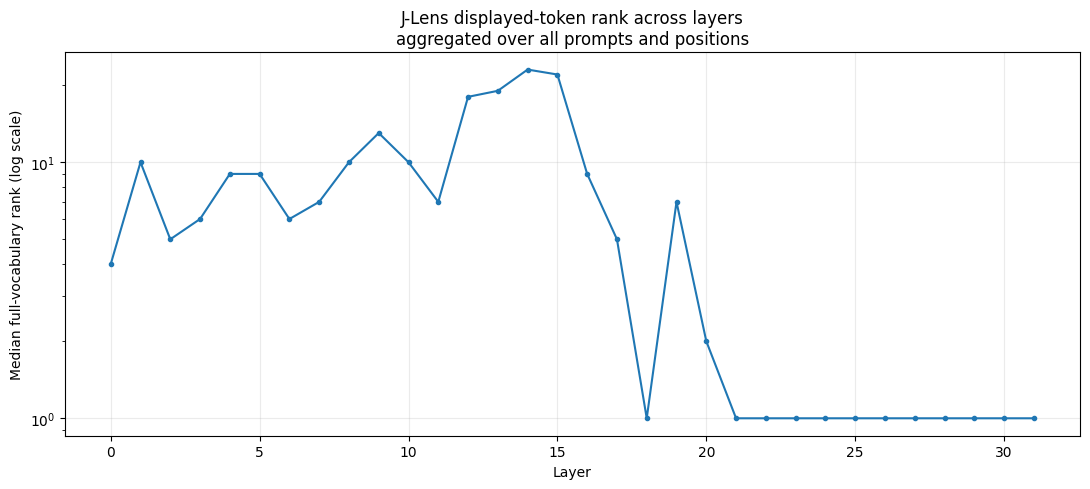

In [42]:
if len(layer_summary):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        layer_summary["layer"],
        layer_summary["median_rank"],
        marker="o",
        markersize=3,
    )
    ax.set_yscale("log")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Median full-vocabulary rank (log scale)")
    ax.set_title(
        "J-Lens displayed-token rank across layers\n"
        "aggregated over all prompts and positions"
    )
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

### Plot B — Fraction of cells whose displayed word-like token is near the top of the full vocabulary

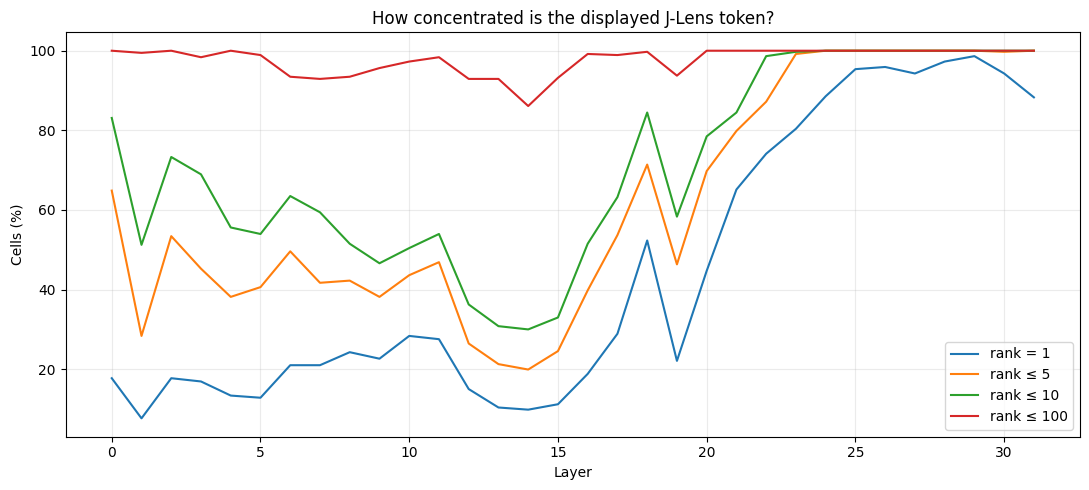

In [43]:
if len(layer_summary):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        layer_summary["layer"],
        layer_summary["rank1_pct"],
        label="rank = 1",
    )
    ax.plot(
        layer_summary["layer"],
        layer_summary["rank5_pct"],
        label="rank ≤ 5",
    )
    ax.plot(
        layer_summary["layer"],
        layer_summary["rank10_pct"],
        label="rank ≤ 10",
    )
    ax.plot(
        layer_summary["layer"],
        layer_summary["rank100_pct"],
        label="rank ≤ 100",
    )

    ax.set_xlabel("Layer")
    ax.set_ylabel("Cells (%)")
    ax.set_title("How concentrated is the displayed J-Lens token?")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

### Plot C — Mean reciprocal rank

MRR is bounded between 0 and 1 and strongly rewards tokens that are genuinely near the top of the vocabulary.

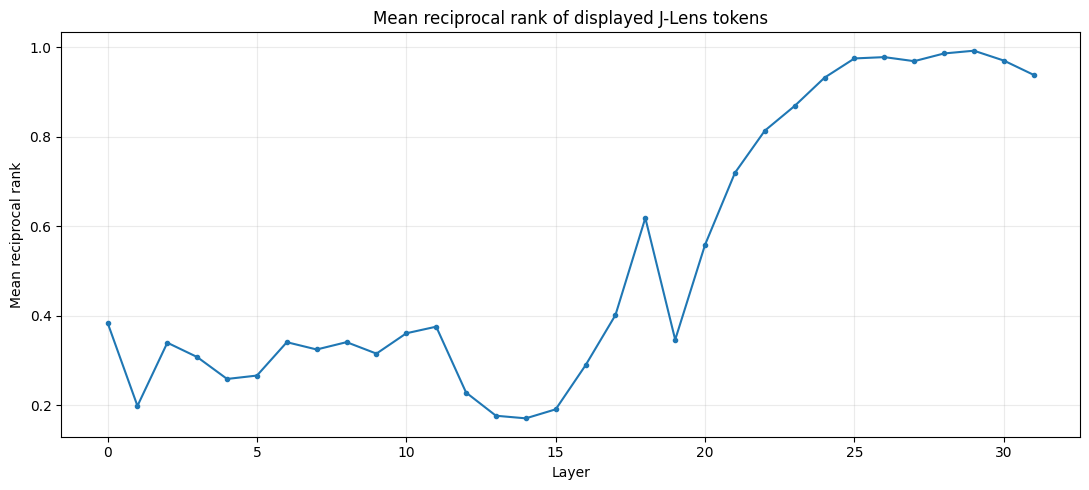

In [44]:
if len(layer_summary):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        layer_summary["layer"],
        layer_summary["mean_reciprocal_rank"],
        marker="o",
        markersize=3,
    )

    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean reciprocal rank")
    ax.set_title("Mean reciprocal rank of displayed J-Lens tokens")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

## 15. Anthropic-like qualitative layer summary: recurring concepts

A numerical rank curve tells us how *concentrated* the readout is, but it does not tell us **what the model is representing**.

The table below surfaces the most recurrent displayed J-Lens tokens at every layer, aggregated over all prompts and positions. Treat frequency cautiously: common tokens can dominate, and frequency alone does not establish importance.

In [45]:
if len(results_df):
    top_n = 8

    token_counts = (
        results_df.groupby(["layer", "top1_token"])
        .size()
        .rename("count")
        .reset_index()
    )

    token_counts["layer_total"] = (
        token_counts.groupby("layer")["count"]
        .transform("sum")
    )
    token_counts["share_pct"] = (
        token_counts["count"]
        / token_counts["layer_total"]
        * 100
    )

    top_by_layer = (
        token_counts.sort_values(
            ["layer", "count"],
            ascending=[True, False],
        )
        .groupby("layer")
        .head(top_n)
        .copy()
    )

    top_by_layer["token"] = (
        top_by_layer["top1_token"]
        .astype(str)
        .str.replace("\n", "\\n", regex=False)
    )

    qualitative_summary = (
        top_by_layer.groupby("layer")
        .apply(
            lambda g: " | ".join(
                f"{repr(r.token)} {r.share_pct:.1f}%"
                for r in g.itertuples()
            ),
            include_groups=False,
        )
        .rename("most_common_displayed_tokens")
        .reset_index()
    )

    qualitative_summary

## 16. Slice-style heatmap for one experiment prompt

Anthropic's interactive slice page is the canonical visualization. For the presentation, it is also useful to preserve a static overview.

This heatmap uses the **full-vocabulary rank** of the displayed word-like token for one prompt.

Rows = layers.  
Columns = prompt token positions.

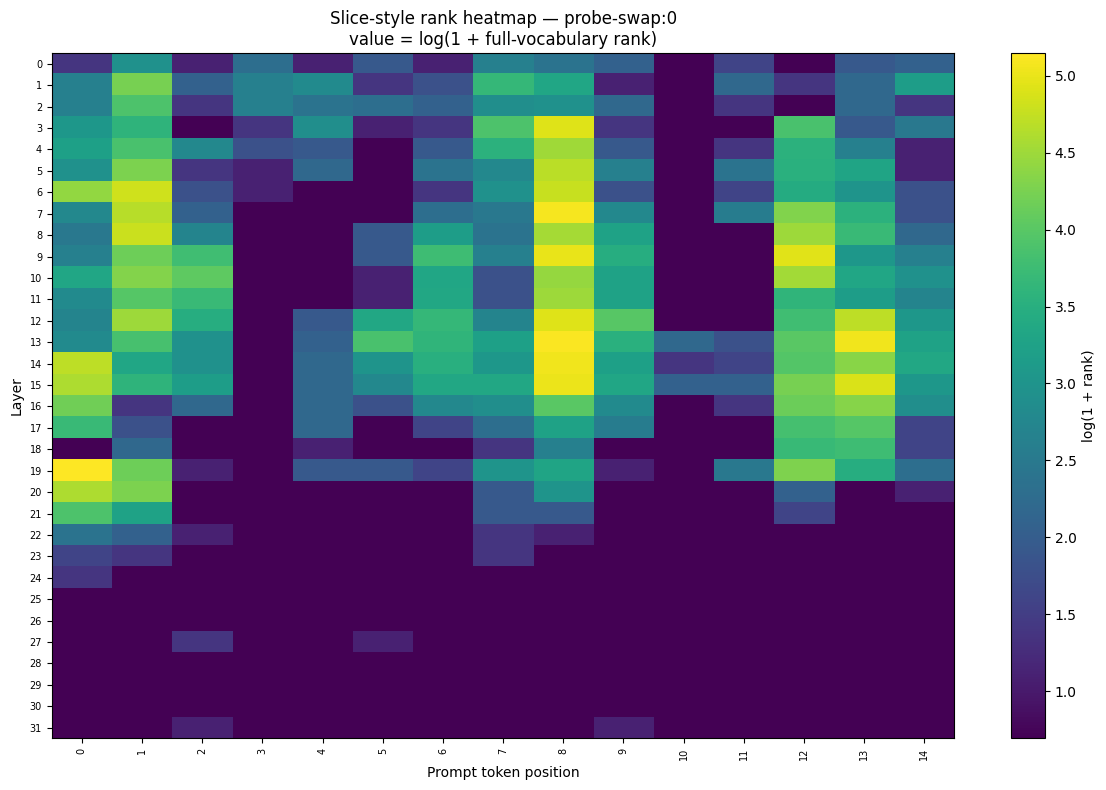

In [46]:
if len(results_df):
    example_prompt_id = results_df["prompt_id"].iloc[0]

    example_df = results_df[
        results_df["prompt_id"] == example_prompt_id
    ].copy()

    rank_grid = example_df.pivot(
        index="layer",
        columns="position",
        values="full_vocab_rank",
    )

    fig, ax = plt.subplots(
        figsize=(max(12, rank_grid.shape[1] * 0.35), 8)
    )

    image = ax.imshow(
        np.log1p(rank_grid.values),
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_xlabel("Prompt token position")
    ax.set_ylabel("Layer")
    ax.set_title(
        f"Slice-style rank heatmap — {example_prompt_id}\n"
        "value = log(1 + full-vocabulary rank)"
    )

    ax.set_xticks(range(rank_grid.shape[1]))
    ax.set_xticklabels(
        rank_grid.columns,
        rotation=90,
        fontsize=7,
    )
    ax.set_yticks(range(rank_grid.shape[0]))
    ax.set_yticklabels(rank_grid.index, fontsize=7)

    fig.colorbar(
        image,
        ax=ax,
        label="log(1 + rank)",
    )

    plt.tight_layout()
    plt.show()

## 17. Optional token-annotated grid

For a shorter prompt, this table is often more interpretable than a color-only heatmap. Each cell is:

`displayed_token [full-vocab-rank]`

In [47]:
if len(results_df):
    annotation_df = example_df.copy()
    annotation_df["cell"] = (
        annotation_df["top1_token"]
        .astype(str)
        .str.replace("\n", "\\n", regex=False)
        + " ["
        + annotation_df["full_vocab_rank"].astype(str)
        + "]"
    )

    token_grid = annotation_df.pivot(
        index="layer",
        columns="position",
        values="cell",
    )

    display(token_grid.iloc[:, : min(30, token_grid.shape[1])])

position,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
layer,,,,,,,,,,,,,,,
0,itious [3],ation [18],部份 [2],of [9],ozen [2],TING [6],later [2],country [13],quiera [10],the [7],Amazon [1],River [4],s [1],however [6],وى [7]
1,itious [13],Â [68],United [7],religious [13],Ă [16],â [3],of [5],country [38],quiera [27],the [2],Amazon [1],River [8],s [3],however [8],Colour [23]
2,ţ [13],ting [49],D [3],of [13],whilst [10],at [9],in [7],e [17],the [18],the [8],Amazon [1],² [3],s [1],at [8],1 [3]
3,itious [20],ONLY [35],The [1],language [3],whilst [17],the [2],of [3],country [49],quiera [137],the [3],Amazon [1],River [1],even [47],the [6],1 [11]
4,ually [24],ONLY [47],The [15],language [5],whilst [6],the [1],of [6],country [34],it [90],the [6],Amazon [1],River [3],s [34],however [13],1 [2]
5,ually [18],ONLY [71],The [3],language [2],spoken [8],the [1],of [10],country [15],people [108],it [13],Amazon [1],River [10],forever [33],however [26],1 [2]
6,ｏ [83],Fact [124],People [5],language [2],spoken [1],the [1],people [3],country [18],it [117],people [5],Amazon [1],river [4],forever [30],only [19],1 [5]
7,a [15],Fact [106],Who [7],language [1],spoken [1],the [1],United [9],countries [11],England [161],people [15],Amazon [1],river [12],forever [73],language [34],1 [5]
8,a [11],Facts [119],Who [14],language [1],spoken [1],Spanish [6],United [23],country [10],Ukraine [93],people [25],Amazon [1],river [1],river [89],language [40],1 [8]


# 18. How to interpret the layers

Use the measurements, not expectations, to write the observations.

Useful questions:

1. **Early layers:** Are displayed word-like tokens generally low-ranked in the full vocabulary? Are they unstable or highly diverse?
2. **Middle layers:** Is there a region where median rank falls or MRR rises? Do interpretable concepts recur?
3. **Late layers:** Does the readout become more concentrated? Do tokens look increasingly connected to immediate continuation/output behavior?
4. **Prompt consistency:** Is the same pattern visible across multiple prompts, or driven by a few examples?
5. **Transition:** Is there an obvious contiguous region where the qualitative nature of the readout changes?
6. **Anomalies:** Do some layers show sudden changes in rank distribution or token diversity?

Do **not** label a region a "global workspace" solely because a rank metric improves. Anthropic's workspace claim relies on multiple functional and causal experiments; our Week 1 table is only a readout diagnostic.

In [48]:
def summarize_layer_regions(summary: pd.DataFrame) -> pd.DataFrame:
    # Rough thirds are descriptive only; they are NOT a workspace-band estimate.
    if summary.empty:
        return pd.DataFrame()

    layers = summary["layer"].to_numpy()
    lo, hi = layers.min(), layers.max()

    def region(layer):
        frac = (layer - lo) / max(1, hi - lo)
        if frac < 1 / 3:
            return "early third"
        if frac < 2 / 3:
            return "middle third"
        return "late third"

    temp = summary.copy()
    temp["region"] = temp["layer"].map(region)

    return (
        temp.groupby("region", sort=False)
        .agg(
            layers=("layer", "count"),
            median_of_layer_median_rank=("median_rank", "median"),
            mean_MRR=("mean_reciprocal_rank", "mean"),
            mean_rank1_pct=("rank1_pct", "mean"),
            mean_rank10_pct=("rank10_pct", "mean"),
            mean_unique_top1=("n_unique_top1", "mean"),
        )
        .reset_index()
    )


region_summary = summarize_layer_regions(layer_summary)
region_summary

,region,layers,median_of_layer_median_rank,mean_MRR,mean_rank1_pct,mean_rank10_pct,mean_unique_top1
0,early third,11,9.0,0.312651,18.479069,59.772108,132.636364
1,middle third,10,8.0,0.335786,24.059946,51.989101,158.400000
2,late third,11,1.0,0.922295,88.382462,98.439435,184.545455


## 19. Optional robustness check: equal weight per prompt

The main assignment says aggregate over all positions and prompts. The cell-weighted summary above therefore gives longer prompts more weight because they contain more positions.

As a robustness check:

1. summarize positions within each `(prompt, layer)`;
2. average those prompt-level summaries at each layer.

If both summaries tell the same qualitative story, the result is less likely to be an artifact of prompt length.

In [49]:
if len(results_df):
    prompt_layer = (
        results_df.groupby(["prompt_id", "layer"], sort=True)
        .agg(
            median_rank=("full_vocab_rank", "median"),
            mean_reciprocal_rank=("reciprocal_rank", "mean"),
            rank1_pct=("rank_eq_1", "mean"),
            rank10_pct=("rank_le_10", "mean"),
            rank100_pct=("rank_le_100", "mean"),
        )
        .reset_index()
    )

    equal_prompt_summary = (
        prompt_layer.groupby("layer", sort=True)
        .agg(
            n_prompts=("prompt_id", "nunique"),
            median_rank=("median_rank", "median"),
            mean_reciprocal_rank=("mean_reciprocal_rank", "mean"),
            rank1_pct=("rank1_pct", "mean"),
            rank10_pct=("rank10_pct", "mean"),
            rank100_pct=("rank100_pct", "mean"),
        )
        .reset_index()
    )

    for col in ["rank1_pct", "rank10_pct", "rank100_pct"]:
        equal_prompt_summary[col] *= 100

    equal_prompt_summary

## 20. Automatic "interesting layers" helper

This cell does not make scientific claims. It simply identifies layers worth inspecting manually in slice-vis:

- highest MRR,
- lowest median rank,
- highest rank≤10 percentage,
- largest adjacent-layer change in median log-rank.

In [50]:
if len(layer_summary):
    interesting = layer_summary.copy()
    interesting["log_median_rank"] = np.log1p(
        interesting["median_rank"]
    )
    interesting["delta_log_median_rank"] = (
        interesting["log_median_rank"].diff()
    )

    best_mrr = interesting.nlargest(
        5,
        "mean_reciprocal_rank",
    )[["layer", "mean_reciprocal_rank"]]

    best_rank = interesting.nsmallest(
        5,
        "median_rank",
    )[["layer", "median_rank"]]

    best_rank10 = interesting.nlargest(
        5,
        "rank10_pct",
    )[["layer", "rank10_pct"]]

    biggest_transitions = (
        interesting.assign(
            abs_delta=lambda d: d[
                "delta_log_median_rank"
            ].abs()
        )
        .nlargest(5, "abs_delta")
        [["layer", "delta_log_median_rank"]]
    )

    print("Highest MRR layers")
    display(best_mrr)

    print("Lowest median-rank layers")
    display(best_rank)

    print("Highest rank≤10 layers")
    display(best_rank10)

    print("Largest adjacent-layer rank changes")
    display(biggest_transitions)

Highest MRR layers


,layer,mean_reciprocal_rank
29,29,0.992507
28,28,0.986376
26,26,0.978202
25,25,0.975250
30,30,0.970481


Lowest median-rank layers


,layer,median_rank
18,18,1.0
21,21,1.0
22,22,1.0
23,23,1.0
24,24,1.0


Highest rank≤10 layers


,layer,rank10_pct
24,24,100.0
25,25,100.0
26,26,100.0
27,27,100.0
28,28,100.0


Largest adjacent-layer rank changes


,layer,delta_log_median_rank
19,19,1.386294
18,18,-1.098612
20,20,-0.980829
12,12,0.864997
16,16,-0.832909


# 21. Results and observations

**Replace the placeholders below after running the notebook.** Keep this section short enough to present, but grounded in the actual outputs above.

### Dataset
- Model: `MODEL_ID`
- Lens: `LENS_FILENAME`
- Experiment prompts processed: **[fill from output]**
- Total prompt × layer × position cells: **[fill from output]**
- Layers summarized: all fitted J-Lens layers **plus the final model-output row**
- Maximum sequence length: `MAX_SEQ_LEN`

### Pipeline validation
- `lens.apply()` token agreement with slice-vis: **[must be 100%]**
- `lens.apply()` rank agreement with slice-vis: **[must be 100%]**

### Layer-wise observations
1. **Early layers:** [What do median ranks, MRR, diversity, and tokens look like?]
2. **Middle layers:** [Is there a more stable/interpretable region? Give layer numbers.]
3. **Late layers:** [How does the readout change as the model approaches output?]
4. **Final model-output row:** [How does it compare with the preceding fitted J-Lens rows?]
5. **Strongest transition:** [Which adjacent layer region changes most?]
6. **Interesting concepts/tokens:** [Mention examples from the qualitative table or slice pages.]

### Limitations
- The number of prompts is constrained by available compute.
- Prompt lengths differ, so the primary table is position-weighted; the equal-prompt robustness table is included.
- The generic loader only collects literal `"prompt"` fields; experiment files that construct prompts from templates need schema-specific builders.
- This Week 1 analysis describes J-Lens readouts only. It does not test bias and does not establish causal workspace behavior.


# 22. Save final artifacts

The notebook itself should be submitted as:

`username_week_1.ipynb`

The CSVs and HTML are useful reproducibility artifacts, but the assignment specifically asks that the important notebook outputs, tables, and visualizations be preserved.

In [51]:
print("Generated files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", path)

print()
print("Before submission:")
print("1. Run all cells top-to-bottom.")
print("2. Confirm the slice-vis renders.")
print("3. Confirm validation is 100%.")
print("4. Preserve the per-layer summary + plots.")
print("5. Fill in the Results and observations markdown.")
print("6. Rename this notebook to <github-username>_week_1.ipynb.")

Generated files:
 - /content/week1_outputs/week1_cell_readouts.csv
 - /content/week1_outputs/week1_full_slice.html
 - /content/week1_outputs/week1_per_layer_summary.csv
 - /content/week1_outputs/week1_slice_validation.csv

Before submission:
1. Run all cells top-to-bottom.
2. Confirm the slice-vis renders.
3. Confirm validation is 100%.
4. Preserve the per-layer summary + plots.
5. Fill in the Results and observations markdown.
6. Rename this notebook to <github-username>_week_1.ipynb.


---

## Appendix — presentation script

A concise methodological explanation:

> "For each prompt token position at every fitted layer, I used `lens.apply()` to obtain the Jacobian Lens vocabulary logits, and I retained the final-model logits as the final slice row. To match Anthropic's slice-vis exactly, I used the repository's meaningful-token mask, the same top-K selection value, and the same full-vocabulary ranking helper. I verified token IDs and ranks against `compute_slice(mask_display=True)`. Then I aggregated all prompt-position cells by layer. The summary reports median rank, reciprocal rank, rank-threshold rates, token diversity, and recurrent displayed concepts."

The most important methodological point is the **100% slice-vis match**. It demonstrates that the batch extraction used for later bias work is measuring the same object you visually inspect in Anthropic's interface.
